In [3]:
import kagglehub
from dotenv import load_dotenv
import os
from ultralytics import YOLO
import yaml
load_dotenv() # Charge les variables du fichier .env

True

In [10]:

# Download latest version
path = kagglehub.dataset_download("khadijaelabbioui/agrivision-unified-plant-disease-18-classes")

print("Path to dataset files:", path)

Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/agrivision-unified-plant-disease-18-classes/versions/1


In [7]:
dataset_root = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/agrivision-unified-plant-disease-18-classes/versions/1"
original_yaml = os.path.join(dataset_root, "dataset.yaml")


with open(original_yaml, 'r') as f:
    config = yaml.safe_load(f)


config['path'] = dataset_root  
config['train'] = 'train/images' 
config['val'] = 'val/images'    


In [8]:
project_root = "/teamspace/studios/this_studio/Projet-Eco-Agronomist-IA-Backend"
config_dir = os.path.join(project_root, "src/ml/configml")
os.makedirs(config_dir, exist_ok=True)

new_yaml_path = os.path.join(config_dir, "agri_plant.yaml")

with open(new_yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False)

print(f"✅ Nouveau fichier de config créé : {os.getcwd()}/{new_yaml_path}")

✅ Nouveau fichier de config créé : /teamspace/studios/this_studio/Projet-Eco-Agronomist-IA-Backend/src/ml//teamspace/studios/this_studio/Projet-Eco-Agronomist-IA-Backend/src/ml/configml/agri_plant.yaml


In [4]:

dataset_path = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/agrivision-unified-plant-disease-18-classes/versions/1"
print(os.listdir(dataset_path))

['train', 'dataset.yaml', 'val']


In [5]:
import torch
import os

# On vérifie la visibilité
print(f"Vérification CUDA : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU détecté : {torch.cuda.get_device_name(0)}")
    
    # Test de calcul sur GPU
    x = torch.rand(5, 3).cuda()
    print("Test de calcul réussi sur GPU !")
else:
    print("CUDA toujours indisponible. Vérifiez l'installation.")

Vérification CUDA : True
GPU détecté : Tesla T4
Test de calcul réussi sur GPU !


In [6]:
!pip install ultralytics


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
def train_yolo_model(data_yaml_path, epochs=50):
    model = YOLO("yolov8s.pt") 

   
    results = model.train(
        data=data_yaml_path,   
        epochs=epochs,         
        imgsz=640,  
        batch=16,
        name='parking_yolov8_plant',  
        optimizer='AdamW', # Très efficace pour les plantes
       lr0=0.01,         # Taux d'apprentissage initial
       augment=True ,        
       device=0,         # Utilise le GPU si présent sur Lightning.ai
    )
    return model

In [16]:
path_to_yaml = os.path.join(dataset_path, "dataset.yaml")
model = train_yolo_model("agri_fixed.yaml", epochs=50)

Ultralytics 8.4.14 🚀 Python-3.12.11 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=agri_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_yolov8_plant5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0

 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 19                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  1   1969152  ultralytics.nn.modules.block.C2f             [768, 512, 1]                 
 22        [15, 18, 21]  1   2123014  ultralytics.nn.modules.head.Detect           [18, 16, None, [128, 256, 512]]
Model summary: 130 layers, 11,142,566 parameters, 11,142,550 gradients, 28.7 GFLOPs

Transferred 349/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1119.0±418.9 MB/s, size: 78.0 KB)
train: Scanning /teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/

✅ Modèle trouvé : runs/detect/parking_yolov8_plant5/weights/best.pt
✅ Dossier images trouvé : /teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/agrivision-unified-plant-disease-18-classes/versions/1/val/images



image 1/1 /teamspace/studios/this_studio/.cache/kagglehub/datasets/khadijaelabbioui/agrivision-unified-plant-disease-18-classes/versions/1/val/images/r_val_00134.jpg: 640x640 2 Tomato leaf bacterial spots, 16.3ms
Speed: 6.3ms preprocess, 16.3ms inference, 26.7ms postprocess per image at shape (1, 3, 640, 640)


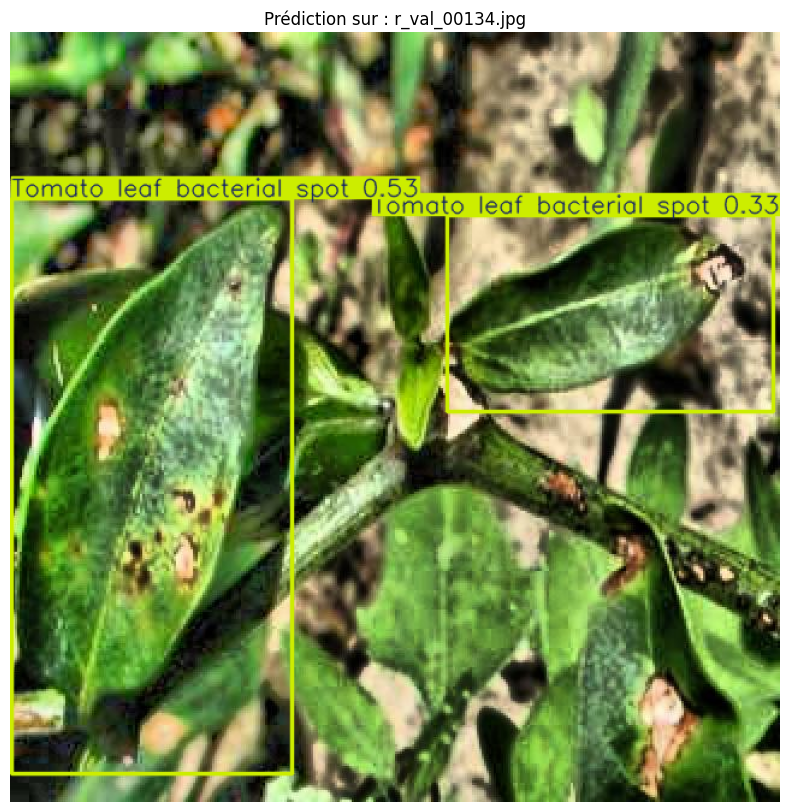

In [3]:
import os
import glob
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# ==========================================================
# 1. LOCALISATION AUTOMATIQUE (Plus d'erreurs de chemin !)
# ==========================================================
# On cherche le fichier best.pt n'importe où dans le dossier ml
model_search = glob.glob("**/parking_yolov8_plant5/weights/best.pt", recursive=True)
# On cherche le dossier val/images dans le cache Kaggle
image_search = glob.glob("/teamspace/studios/this_studio/.cache/kagglehub/**/val/images", recursive=True)

if not model_search or not image_search:
    print(" Erreur : Modèle ou images introuvables. Vérifie tes dossiers à gauche.")
else:
    MODEL_PATH = model_search[0]
    IMG_DIR = image_search[0]
    print(f"✅ Modèle trouvé : {MODEL_PATH}")
    print(f"✅ Dossier images trouvé : {IMG_DIR}")

    # ==========================================================
    # 2. CHARGEMENT ET PRÉDICTION
    # ==========================================================
    model = YOLO(MODEL_PATH)
    
    # On prend la première image du dossier
    img_name = [f for f in os.listdir(IMG_DIR) if f.endswith(('.jpg', '.png'))][0]
    img_path = os.path.join(IMG_DIR, img_name)
    
    # Lancement de l'inférence
    results = model.predict(source=img_path, conf=0.25)

    # ==========================================================
    # 3. AFFICHAGE DU RÉSULTAT
    # ==========================================================
    for r in results:
        # On convertit le résultat en image lisible par Matplotlib
        im_rgb = cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(im_rgb)
        plt.title(f"Prédiction sur : {img_name}")
        plt.axis('off')
        plt.show()